# TP1 Modèles de langue: exploration de la tokenization et des embeddings

Dans ce TP nous allons explorer un peu la tokenization d'un modèle de langue, en regardant par exemple la correspondance avec les mots d'un dictionnaire classique.

Puis nous allons étudier l'espace de représentation des embeddings associés aux sous-tokens dans un modèle, et tester si les mots proches en sens sont tokenisés avec des sous-tokens proches.

Enfin, nous visualiserons les correspondances entre 2 langues dans l'espace des représentations créé par un modèle multilingue.

In [1]:
# pour faire de la réduction de dimension de l'espace des embeddings
%pip -q install umap-learn
# dictionnaire multilingue de traductions mot -> mot
%pip -q install word2word

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# lexique de mots anglais
#%wget https://www.irit.fr/~Philippe.Muller/lexicon.txt.gz
#%gunzip lexicon.txt.gz

In [3]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pds

/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForMaskedLM
import torch
import pandas as pds
import itertools
import gzip

In [5]:
import word2word

In [6]:
# on peut essayer différents modèles, mais seul le dernier est multilingue
#MODEL = "bert-base-uncased"
#MODEL = "roberta-base"
MODEL = "bert-base-multilingual-cased"
cpt = {}

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [8]:
pathfile = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TALNGG/TP_2025/TP1_TAL_2025_26/lexicon.txt"
lexicon = set([x.strip() for x in open(pathfile).readlines()])

# Tokenization

- Appliquer le tokenizer associé à des modèles listés plus haut, à tous les mots du lexique anglais, pour récupérer tous les sous-mots utilisés, et faites un comptage du nombre de mots dans lequel chacun apparait.

Que peut-on dire des plus fréquents ?

(conseils: le faire en un seul appel au tokenizer, pas mot à mot; le comptage peut être fait avec le module collections.Counter de python ou bien pandas)

- A quoi correspondent les symboles spéciaux ?

- Créer un dictionnaire qui associe à chaque mot du lexique la liste des sous-tokens qui le composent
(pour être plus efficace, vous pouvez prendre la liste des sous-mots générés à la 1er question; la 2e question est important aussi !)


In [9]:
# warning does not matter since we just want the decomposition in subtokens
subtokens = tokenizer.tokenize(" ".join(lexicon),add_special_tokens=False)
#print(len(subtokens))
from collections import Counter
cpt = Counter(subtokens)
print(cpt.most_common(20))

Token indices sequence length is longer than the specified maximum sequence length for this model (314484 > 512). Running this sequence through the model will result in indexing errors


[('-', 3445), ('##d', 2873), ('##y', 2564), ('##e', 2445), ('##ly', 2014), ('##ing', 1993), ('##s', 1942), ('##ed', 1927), ('##l', 1712), ('##r', 1635), ('in', 1465), ('##t', 1462), ('##us', 1452), ('##te', 1392), ('s', 1343), ('##er', 1330), ('##c', 1210), ('c', 1204), ('##ness', 1199), ('##n', 1167)]


In [10]:
subtokens[:10]

['prof',
 '##fere',
 '##r',
 'bol',
 '##ling',
 'str',
 '##obil',
 '##ae',
 'instant',
 '##ane']

In [11]:
# ids for each subtokens,
subtokens_ids = tokenizer(" ".join(lexicon),add_special_tokens=False)["input_ids"]
assert len(subtokens_ids)==len(subtokens)

In [12]:
from collections import defaultdict

w2tok = {}
# pas nécessaire pour le TP sauf si on veut tester une tokenization maligne genre FLOTA
# garde tous les mots dans lesquel le token apparait: permet par exemple de savoir quelles sous-tokens
# sont des mots complets
tok2w = defaultdict(list)
tok2id = {}
id2tok = {}
current = []
# les sous-tokens sont dans l'ordre de l'appel du tokenize, donc il suffit de savoir
# quelle sous-chaine démarre un mot pour découper la liste en mot:
# dans Bert/Roberta, un sous-mot qui ne démarre pas une chaine commence avec un caractère spécial ("Ġ") ou
# 2 ("##"); Pour certains tokenizers (sentencepiece) c'est le début d'un mot qui commence par un caractère spécial
# ("_" ou " " selon les modèles)
for i,tok in enumerate(subtokens):
    tok2id[tok] = subtokens_ids[i]
    id2tok[i] = tok
    # covers BPE and wordpiece convention
    if tok.startswith("Ġ") or not(tok.startswith('##')):
        if current!=[]:
            word = "".join(current).replace("Ġ","").replace("##","")
            w2tok[word] = current
            for t in current:
                tok2w[t].append(word)
            current = []
    current.append(tok) #no, different embedding ... replace("Ġ",""))


In [13]:
len(tok2w)

16295

In [14]:
# un petit échantillon pour vérifier
[(i,x) for i,x in enumerate(w2tok.items()) if i<10]

[(0, ('profferer', ['prof', '##fere', '##r'])),
 (1, ('bolling', ['bol', '##ling'])),
 (2, ('strobilae', ['str', '##obil', '##ae'])),
 (3, ('instantaneous', ['instant', '##ane', '##ous'])),
 (4, ('bunsen', ['bun', '##sen'])),
 (5, ("'", ["'"])),
 (6, ('s', ['s'])),
 (7, ('burner', ['bu', '##rner'])),
 (8, ('filtering', ['filter', '##ing'])),
 (9, ('pleuroptera', ['pl', '##eur', '##optera']))]

# Analyse des embeddings de base préentrainés

Charger un des modèles avec la library transformers avec AutoModelForMaskedLM.

Affichez la structure du modèle pour trouvez la matrice d'embeddings des sous tokens du vocabulaire du modèle.

Quelle est sa taille ? Quelle est la dimension des embeddings ?

In [15]:
model = AutoModelForMaskedLM.from_pretrained(MODEL)
if MODEL.startswith("bert"):
        base = model.bert
elif MODEL.startswith("roberta"):
        base = model.roberta
else:
    print("unknown model",MODEL)

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [16]:
model

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [17]:
base

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=Fals

In [18]:
initial_embed_matrix = base.embeddings.word_embeddings._parameters["weight"]

In [19]:
print(initial_embed_matrix.shape)

torch.Size([119547, 768])


## Similarité de mots

- Testez la similarité de deux sous-tokens qui sont aussi des mots (pour faire plus simple), en utilisant la similarité cosinus (dans torch.nn) entre leur vecteur d'embedding de base.

- Testez aussi quelques mots de langues différentes avec le modèle multilingue
(par exemple chien/dog)

In [20]:
# testing similarity of embeddings
from torch.nn import CosineSimilarity
a , b = tokenizer("dog chien",add_special_tokens=False)["input_ids"]
CosineSimilarity(dim=0)(initial_embed_matrix[a],initial_embed_matrix[b])

tensor(0.2162, grad_fn=<SumBackward1>)

# Visualisation

On va maintenant faire une réduction de dimension pour essayer de voir des régularités de l'espace des embeddings ("espace latent")

Nous utiliserons la méthode UMAP qui est bien adaptée en grande dimension, avec les paramètres suivants

In [21]:
# vous pouvez faire varier les 2 premiers pour voir, mais attention le calcul est assez long
params={"n_neighbors":15,
        "min_dist":0.1,
        "n_components":2,
        "metric":"euclidean",
       }

On peut appeler la méthode comme suit.

In [22]:
reducer = umap.UMAP(random_state=42,**params)
# méthode alternative plus lente
# reducer = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=3)
#-------
# attention meme umap va prendre quelques minutes ! (~5mn dans colab)
%time  redux = reducer.fit_transform(initial_embed_matrix.detach().numpy())

/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 2min 17s, sys: 3.01 s, total: 2min 20s
Wall time: 1min 47s


redux est maintenant une nouvelle représentation des sous-tokens dans un espace en 2 dimensions. Vérifiez sa taille.
On va visualiser seulement les sous-tokens les plus courants pour ne pas trop surcharger.
Récupérer les indices des N=1000 (par exemple) sous-tokens les plus courants à partir du comptage fait plus haut.


In [23]:
redux.shape

(119547, 2)

In [24]:
top100 = cpt.most_common(1000)
top100_id = [tok2id[x] for x,_ in top100]

In [25]:
len(top100_id)

1000

(1000, 2)


/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 34532 (\N{CJK UNIFIED IDEOGRAPH-86E4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26224 (\N{CJK UNIFIED IDEOGRAPH-6670}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/asriel/miniconda3/envs/umap_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 38452 (\N{CJK UNIFIED IDEOGRAPH-9634}) missing from font

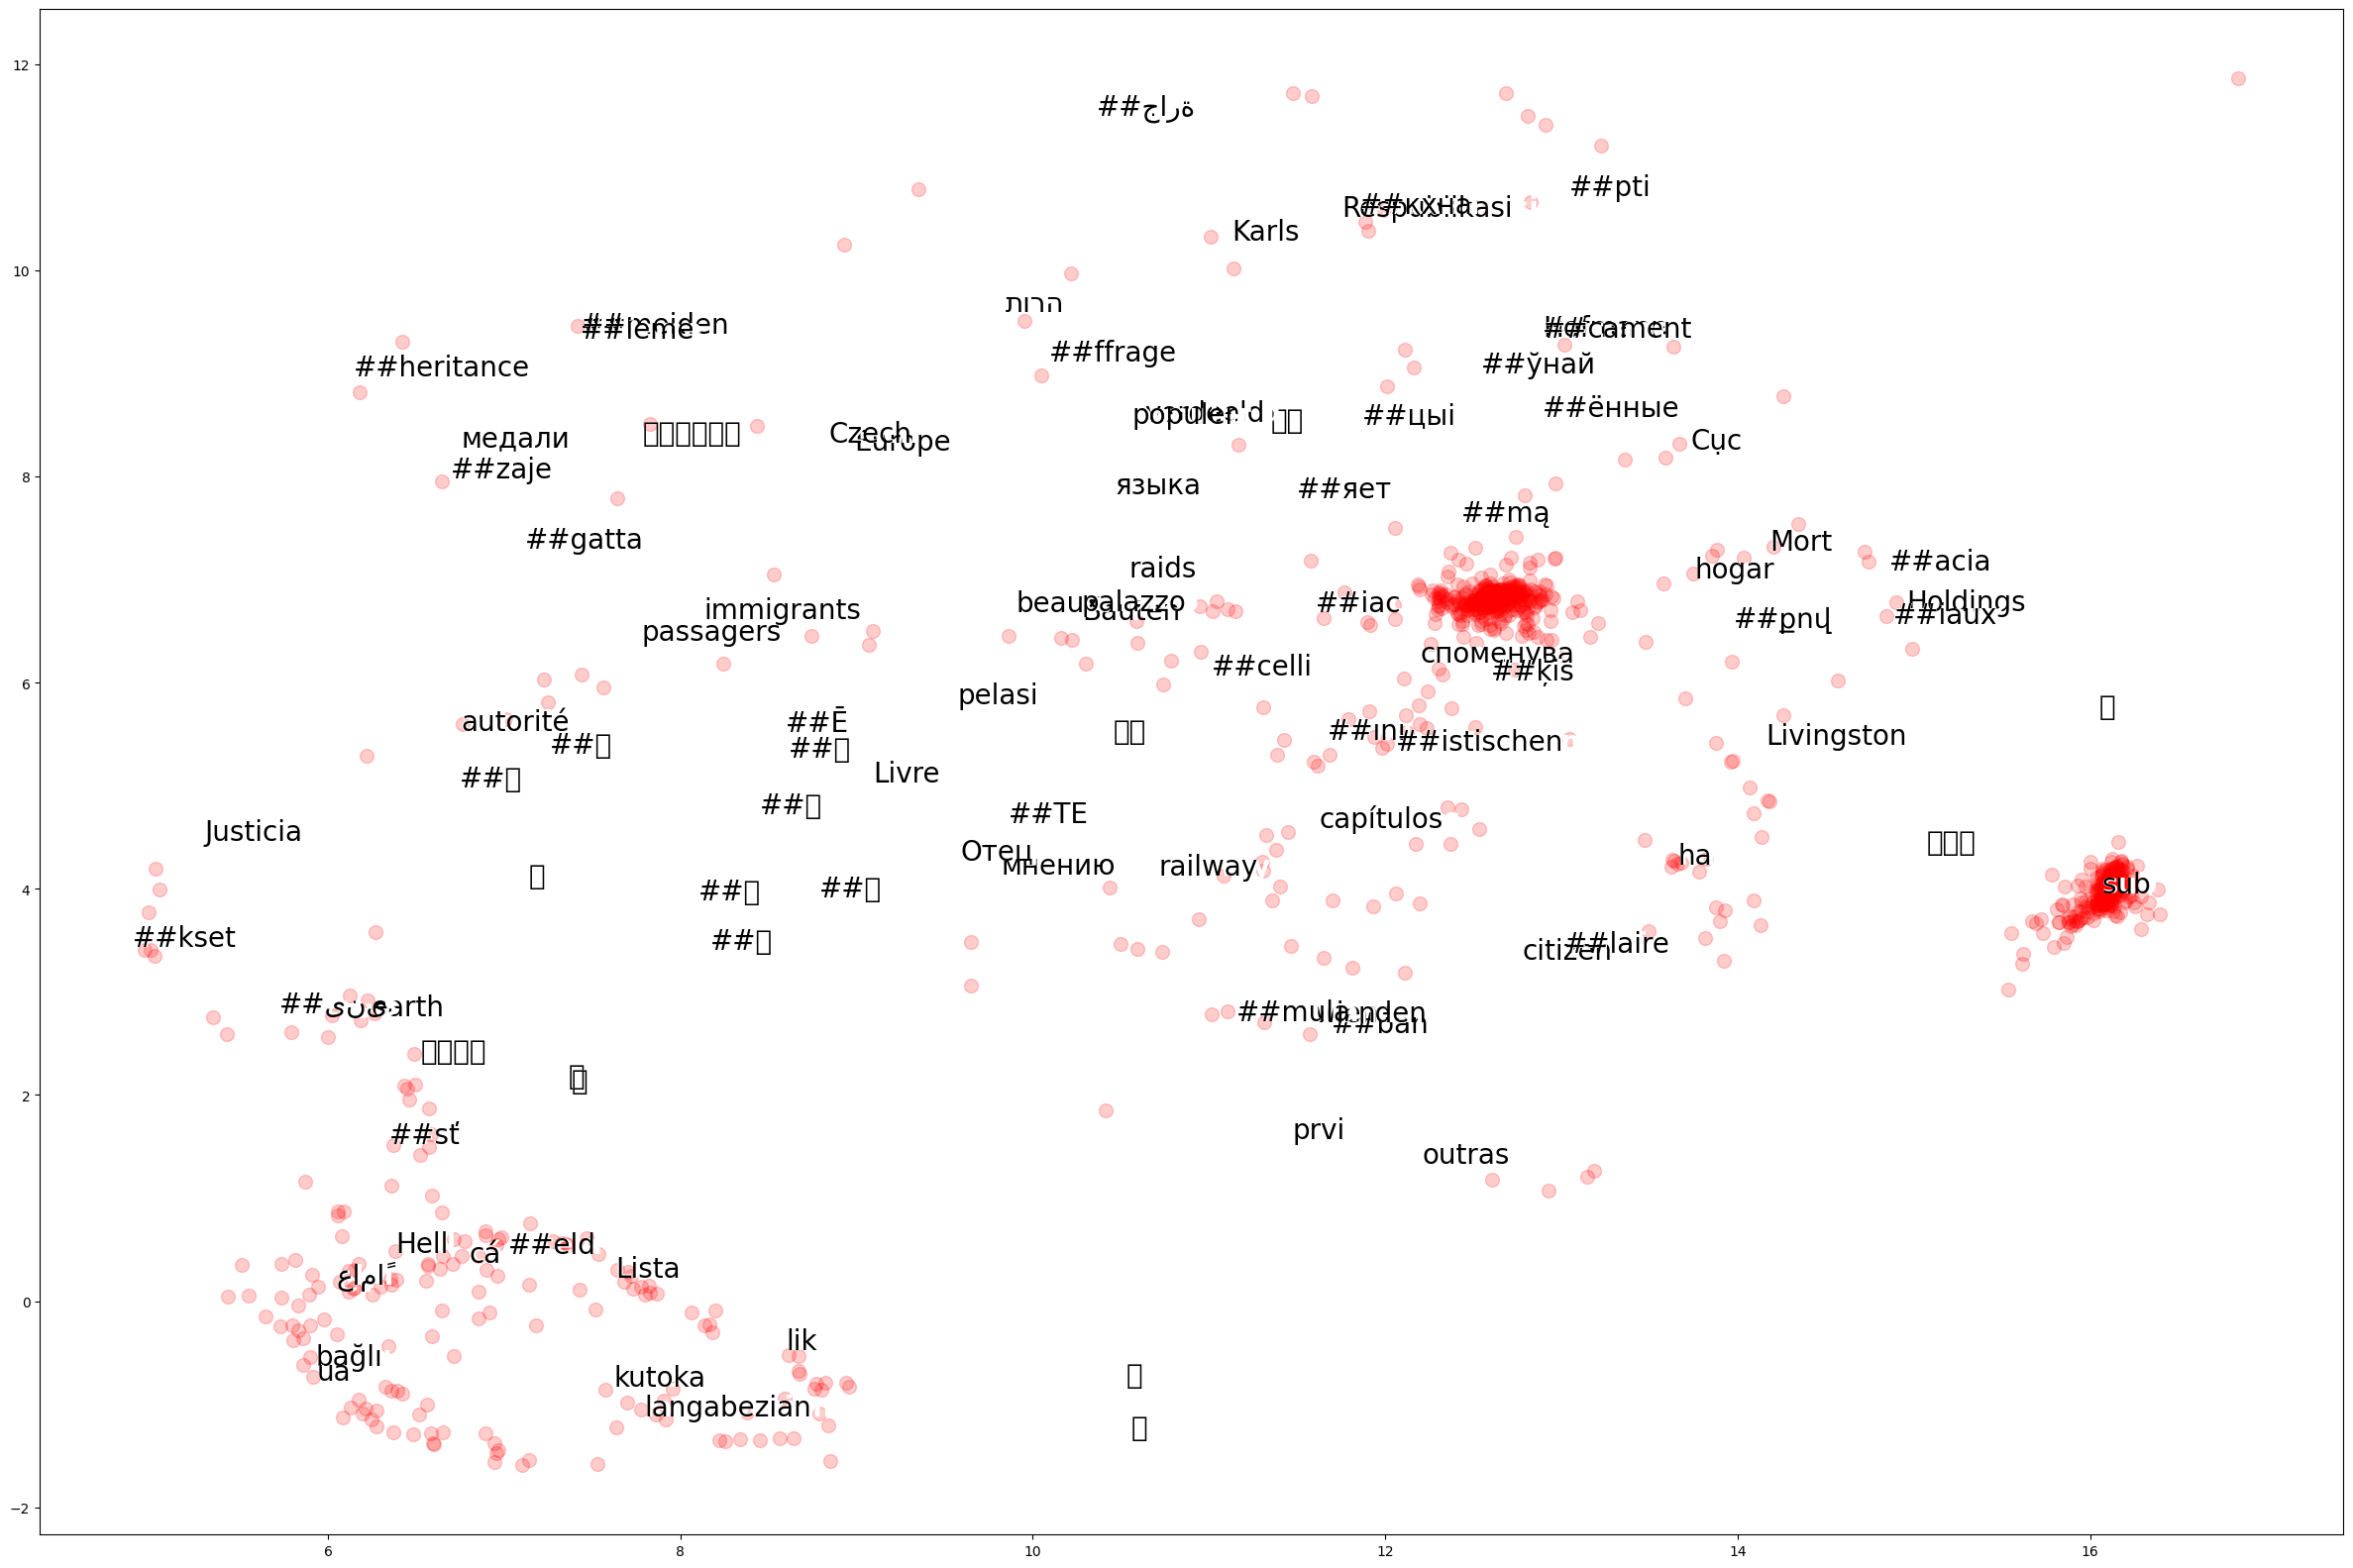

In [26]:
from numpy import random
# ce code affiche la projection en 2D, avec la chaine correspondant à chaque sous-token pour un échantillon
# au hasard
# remplacez l'échantillon par les N sous-tokens les plus courants et observez la différence
fig, ax = plt.subplots(figsize=(30, 20))
#plt.scatter(redux[:, 0], redux[:, 1],alpha=0.1)
top100_pt = redux[np.array(top100_id)]
print(top100_pt.shape)
plt.scatter(top100_pt[:,0],top100_pt[:,1],s=100,c="r",alpha=0.2)
#
sample = random.randint(redux.shape[0],size=100)
for idx in list(sample.data):
    ax.annotate(tokenizer.convert_ids_to_tokens(idx),redux[idx],size=20,c="w",weight="bold")
    ax.annotate(tokenizer.convert_ids_to_tokens(idx),redux[idx],size=20)

In [27]:
# sauve les résultats au cas où
# (pas demandé)
# output
# each line is one token with word information
# word_id; x; y; word_form; frequency of subtoken in the vocabulary

all = []

model_name = "mbert"
proj = "umap"

with open(f"word_projections_{model_name}_{proj}.csv","w") as f:
        columns = "Id;x;y;word;frequency;token".split(";")
        print(";".join(columns),file=f)
        for i,word in enumerate(w2tok):
            for tok in w2tok[word]:
                instance = (i,
                            redux[tok2id[tok],0],
                            redux[tok2id[tok],1],
                            word,
                            cpt[tok],
                            tok
                           )
                all.append(instance)
                print(";".join(map(str,instance)),file=f)

In [28]:
df_word = pds.DataFrame(all,columns=columns)

In [29]:
# each line is a token with projection and frequency in vocabulary (when available)
all = []
with open(f"token_projections_{model_name}_{proj}.csv","w") as f:
        columns = "Id;x;y;frequency;tok".split(";")
        print(";".join(columns),file=f)
        for idx in range(redux.shape[0]): # dim0 = point id
                tok = tokenizer.convert_ids_to_tokens(idx)
                instance = (idx,
                            redux[idx,0],
                            redux[idx,1],
                            cpt.get(tok,0),
                            tok
                           )
                all.append(instance)
                print(";".join(map(str,instance)),file=f)

In [30]:
df_tokens = pds.DataFrame(all,columns=columns)

<Axes: ylabel='Frequency'>

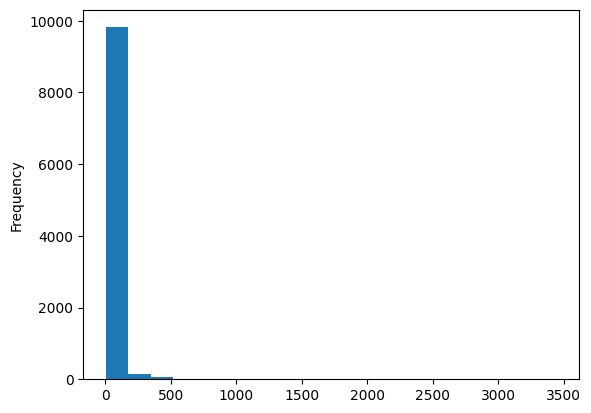

In [31]:
(df_tokens[df_tokens["frequency"]>2]["frequency"]).plot(kind="hist",bins=20)

In [32]:
#df_tokens["initial"] = df_tokens["tok"].str.startswith("Ġ")
df_tokens["initial"] = ~(df_tokens["tok"].str.startswith("##"))
start = 20000
df_tokens.iloc[start:start+30]


,Id,x,y,frequency,tok,initial
20000,20000,6.009770,0.240440,0,broju,True
20001,20001,5.775668,0.011525,0,थन,True
20002,20002,9.572556,5.886045,0,entstand,True
20003,20003,10.689229,1.666400,0,Dallas,True
20004,20004,13.021705,7.032080,0,##ад,False
20005,20005,5.804327,-0.144847,0,toàn,True
20006,20006,6.791987,-0.376744,1,passed,True
20007,20007,12.870729,7.356584,0,##ово,False
20008,20008,9.035884,8.022085,0,Queensland,True
20009,20009,6.098361,0.013522,0,horien,True


In [33]:
len(df_tokens)

119547

# Traduction / mapping entre langues

On va charger un dictionnaire bilingue avec la librairie word2word:

In [34]:
en2fr = word2word.Word2word("en", "fr")

Pour simplifier on va juste regarder la première traduction proposée pour chaque mot anglais qui est un sous-token dans un modèle multilingue comme mBert.

- Vérifiez le contenu du mapping en2fr, prenez un exemple, et calculez le mapping sous-token anglais -> mot français qui est aussi un sous-token du modèle.
Cela nous donnera un ensemble de mot en/fr qui sont dans le vocabulaire des sous-tokens du modèle.

- On va maintenant regarder pour chaque token "anglais" quel est le token "français" le plus proche: calculez cette association avec la similarité cosinus. On peut sauver le tout dans une table pandas.

- regardez la distribution des similarités. regardez les valeurs à 1, et les valeurs élevées mais <1 (par exemple 0.5-.99)

In [35]:
# contenu du dictionnaire ?
en2fr.__dict__.keys()

dict_keys(['lang1', 'lang2', 'word2x', 'y2word', 'x2ys', 'summary'])

In [36]:
"!" in en2fr.word2x

True

In [37]:
# test
en2fr('militia')

['milice', 'miliciens', 'Milice', 'armée', 'guerre']

In [38]:
df_en = df_tokens[(df_tokens['tok'].isin(en2fr.word2x)) & (df_tokens["initial"])]

In [39]:
df_en["tok"].values

array(['!', '"', '#', ..., 'dust', 'Fargo', 'Manon'], dtype=object)

In [40]:
fr_translation = [(en2fr(word)[0] if len(word)>1 else word) for word in df_en["tok"].values]

In [41]:
df_en["french_word"] = fr_translation
df_en["lang"] = "en"

/var/folders/qp/m4x_nf996xq9pxj7nm2t9ffr0000gn/T/ipykernel_69346/3389707395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_en["french_word"] = fr_translation
/var/folders/qp/m4x_nf996xq9pxj7nm2t9ffr0000gn/T/ipykernel_69346/3389707395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_en["lang"] = "en"


In [42]:
df_en

,Id,x,y,frequency,tok,initial,french_word,lang
106,106,16.404285,3.811509,0,!,True,!,en
107,107,16.457422,3.771865,5,"""",True,"""",en
108,108,16.210115,3.887499,1,#,True,#,en
109,109,7.109030,3.851279,0,$,True,$,en
110,110,16.582239,11.674550,0,%,True,%,en
...,...,...,...,...,...,...,...,...
110760,110760,8.112963,7.447268,0,Mystic,True,Falls,en
110761,110761,8.003270,7.253463,51,palm,True,paume,en
110790,110790,8.210198,6.955673,13,dust,True,poussière,en
110843,110843,7.971376,7.389324,0,Fargo,True,Fargo,en


In [43]:
df_french = df_tokens[(df_tokens['tok'].isin(set(fr_translation)))]

In [44]:
df_french["lang"]="fr"

/var/folders/qp/m4x_nf996xq9pxj7nm2t9ffr0000gn/T/ipykernel_69346/2910347249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_french["lang"]="fr"


In [45]:
from tqdm import tqdm
from torch.nn import CosineSimilarity

cos = CosineSimilarity(dim=0)

res = []
sim = []
# this is suboptimal but ...
for i,v in tqdm(list(df_en.iterrows())):
    #print(v["tok"],end="->")
    en_tok = v["tok"]
    if len(en_tok)==1:# single char no need to translate
        out = v["Id"]
        s = 1
    else:
        match = df_french.loc[df_french["tok"]==v["french_word"]]
        if len(match)>0:
            out = (match["Id"].iloc[0])
            # similarity in original space, not projected
            s = cos(initial_embed_matrix[v["Id"]],initial_embed_matrix[out]).detach().numpy()
        else:
            out = None
            s = 0
    #print(out)
    res.append(out)
    sim.append(s)


100%|██████████| 14435/14435 [00:05<00:00, 2435.47it/s]


In [46]:
len(res)

14435

In [47]:
df_en["french_id"] = pds.Series([(x if x is not None else -1) for x in res],dtype=object)
df_en["distance"] = sim

/var/folders/qp/m4x_nf996xq9pxj7nm2t9ffr0000gn/T/ipykernel_69346/3666438923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_en["french_id"] = pds.Series([(x if x is not None else -1) for x in res],dtype=object)
/var/folders/qp/m4x_nf996xq9pxj7nm2t9ffr0000gn/T/ipykernel_69346/3666438923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_en["distance"] = sim


In [48]:
df_en.head(100)

,Id,x,y,frequency,tok,initial,french_word,lang,french_id,distance
106,106,16.404285,3.811509,0,!,True,!,en,21934,1
107,107,16.457422,3.771865,5,"""",True,"""",en,44271,1
108,108,16.210115,3.887499,1,#,True,#,en,37718,1
109,109,7.109030,3.851279,0,$,True,$,en,11051,1
110,110,16.582239,11.674550,0,%,True,%,en,59645,1
...,...,...,...,...,...,...,...,...,...,...
254,254,16.063564,3.822707,0,à,True,à,en,10365,1
263,263,15.872209,3.908800,0,é,True,é,en,10391,1
509,509,16.171951,4.307346,0,А,True,А,en,11100,1
1775,1775,7.110924,3.832151,0,€,True,€,en,14941,1


In [49]:
both = pds.concat([df_en,df_french])
both.head(-100)

,Id,x,y,frequency,tok,initial,french_word,lang,french_id,distance
106,106,16.404285,3.811509,0,!,True,!,en,21934,1
107,107,16.457422,3.771865,5,"""",True,"""",en,44271,1
108,108,16.210115,3.887499,1,#,True,#,en,37718,1
109,109,7.109030,3.851279,0,$,True,$,en,11051,1
110,110,16.582239,11.674550,0,%,True,%,en,59645,1
...,...,...,...,...,...,...,...,...,...,...
107979,107979,6.940590,9.913580,0,Wilton,True,NaN,fr,NaN,NaN
108022,108022,6.672951,9.934769,0,Potomac,True,NaN,fr,NaN,NaN
108057,108057,6.917563,9.962228,0,Astor,True,NaN,fr,NaN,NaN
108061,108061,6.400571,-4.216331,0,16e,True,NaN,fr,NaN,NaN


<Axes: ylabel='Frequency'>

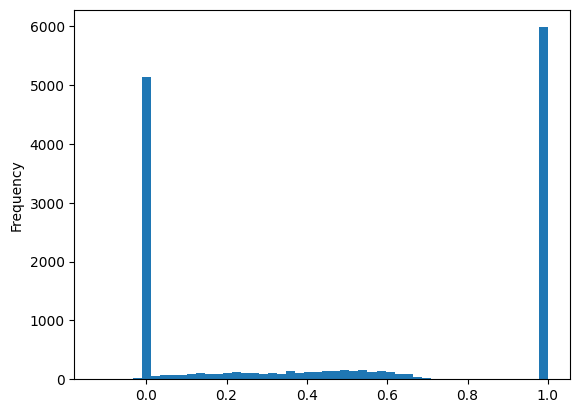

In [50]:
both["distance"].dropna().astype(float).plot(kind="hist",bins=50)

In [51]:
both[(both["distance"]>0.5) & (both["distance"]<0.99)]

,Id,x,y,frequency,tok,initial,french_word,lang,french_id,distance
10204,10204,8.469516,3.824293,0,km,True,Km,en,-1,0.5167383
10276,10276,12.859605,16.819595,0,2002,True,2003,en,-1,0.8599317
10279,10279,15.745967,3.763777,13,han,True,Han,en,-1,0.588146
10285,10285,15.994431,3.735581,23,las,True,Las,en,63255,0.6111728
10379,10379,14.718795,2.136884,1,also,True,également,en,64100,0.5601817
...,...,...,...,...,...,...,...,...,...,...
108094,108094,7.288482,9.629665,0,Hitlers,True,Hitler,en,NaN,0.5649751
109257,109257,11.409068,8.154850,0,alternatives,True,alternative,en,NaN,0.57901156
109332,109332,7.423734,8.225103,0,Judo,True,judo,en,NaN,0.72362304
109358,109358,10.658208,5.372095,0,corporations,True,sociétés,en,NaN,0.50024384


## Analyse

- que peut-on dire des mots les plus proches ?

- si on veut vérifier que les traductions sont toujours proches on va reprendre la projection de l'espace latent en affichant les traductions et la distance mot-traduction dans la figure en utilisant le code suivant.

- Que concluez vous sur les embeddings du modèle considéré ?

In [52]:
# visualisation interactive des tokens
import plotly.express as px
# remplacez par ce que vous avez trouvé comme ensemble de mots qui sont des mots anglais
# et des mots français.
# le code suppose que target a
#  - des champs x et y pour les coordonnées de la projection umap
#  - un champ pour dire dans quel langue le token est un mot
#  optionnellement: (la figure peut se faire sans mais c'est moins intéressant)
#  - un champ tok qui donne la chaine du token
#  - un champ french_word pour la traduction du mot en français (si mot pas français)
#  - un champ distance pour la distance cosinus entre le mot et sa traduction
#target = both[both["tok"]!=both["french_word"]]
target = both

fig = px.scatter(both, x="x", y="y", color="lang",
                 color_discrete_sequence=['black','red'],
                 #size='frequency',
                 hover_name='tok',hover_data=["french_word","distance"],
                width=1200, height=800,
                template="seaborn")

fig.update_traces(opacity=.1)
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

# Question Bonus:

refaire la visualisation de l'espace latent avec la projection finale des mots anglais passés dans le modèle *encodeur*

vous pouvez utiliser les fonctions suivantes qui appelent un modèle encodeur sur une liste de mot et récupérent les activations de chaque couche moyennées sur les sous-tokens d'un mot

vous pouvez le faire avec un échantillon de mots au hasard

In [ ]:
# appel du modèle + recup toutes les couches visées en les sommant
def get_hidden_states(encoded, token_ids_word, model, layers):
    # inference
    with torch.no_grad():
        output = model(**encoded,output_hidden_states=True)
    # get all hidden states
    states = output.hidden_states
    # stack and sum layers
    output = torch.stack([states[i] for i in layers]).sum(0).squeeze()
    # subset for tokens that make up the word, averaged on subtokens
    word_tokens_output = output[token_ids_word]
    return word_tokens_output.mean(dim=0)

# encode the sentence, get vector representing the word at index idx for given layers
def get_word_vector(sent, idx, tokenizer, model, layers, device):
    # tokenize the input sentence and sending to device
    encoded = tokenizer.encode_plus(sent, add_special_tokens=True, return_tensors="pt").to(device)
    # get all token idxs that make up the target word
    token_ids_word = np.where(np.array(encoded.word_ids()) == idx)
    # get all hidden states
    return get_hidden_states(encoded, token_ids_word, model, layers)

# main function to get encoding vector of given word occuring in a given sentence
# layers = set of layers to average for the representation
# if want only the last one call with layers = [-1]
def get_embedding(model, tokenizer, sent, word, device, layers=None):
    # using last four layers by default
    layers = [-4, -3, -2, -1] if layers is None else layers
    # get idx for the word
    idx = sent.split(" ").index(word)
    #print(idx)
    # get word embedding
    word_embedding = get_word_vector(sent, idx, tokenizer, model, layers, device)
    return word_embedding

In [ ]:
v1 = get_embedding(model,tokenizer,"thirty cat","thirty","cpu",layers=[-1,-2])
v2 = get_embedding(model,tokenizer,"thirty cat","cat","cpu",layers=[-1,-2])

CosineSimilarity(dim=0)(v1,v2)

tensor(0.8560)

In [ ]:
sent1 = ""
v1 = get_embedding(model,tokenizer,"dog cat","dog","cpu",layers=[-1,-2])
v2 = get_embedding(model,tokenizer,"dog cat","cat","cpu",layers=[-1,-2])

CosineSimilarity(dim=0)(v1,v2)

In [ ]:
device = "cpu"
layers = [-4,-3,-2,-1]
idx = 0
v = get_word_vector("dog", idx, tokenizer, model, layers, device)
v.shape

torch.Size([768])